In [1]:
import csv
import pandas as pd

In [2]:
params = {
    'fileLocation': 'database\\winemag-data-130k-v2_clean.csv',
}

In [3]:
df = csv.reader(open(params['fileLocation'], 'r', encoding='utf-8'))
columns = next(df)
columns[0] = 'id'  # Az első oszlop neve 'id' legyen
df = pd.DataFrame(df, columns=columns)

print(df.shape)
display(df.head())

(129971, 7)


,id,country,description,points,province,region_1,region_2
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",87,Sicily & Sardinia,Etna,
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",87,Douro,,
2,2,US,"Tart and snappy, the flavors of lime flesh and...",87,Oregon,Willamette Valley,Willamette Valley
3,3,US,"Pineapple rind, lemon pith and orange blossom ...",87,Michigan,Lake Michigan Shore,
4,4,US,"Much like the regular bottling from 2012, this...",87,Oregon,Willamette Valley,Willamette Valley


In [4]:
df_description = df[['id', 'country', 'points', 'province']].copy()
# df_description.head(5)

df_description['group'] = pd.qcut(df_description['points'].astype(int),
                                 q=4,
                                 labels=['poor', 'below_avg', 'above_avg', 'excellent'])

# display(df_description['group'].value_counts())
display(df_description.head(5))

,id,country,points,province,group
0,0,Italy,87,Sicily & Sardinia,below_avg
1,1,Portugal,87,Douro,below_avg
2,2,US,87,Oregon,below_avg
3,3,US,87,Michigan,below_avg
4,4,US,87,Oregon,below_avg


C:\Users\2314l\AppData\Local\Temp\ipykernel_19848\1897216591.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_avg_points.index, y=country_avg_points.values, palette="viridis")


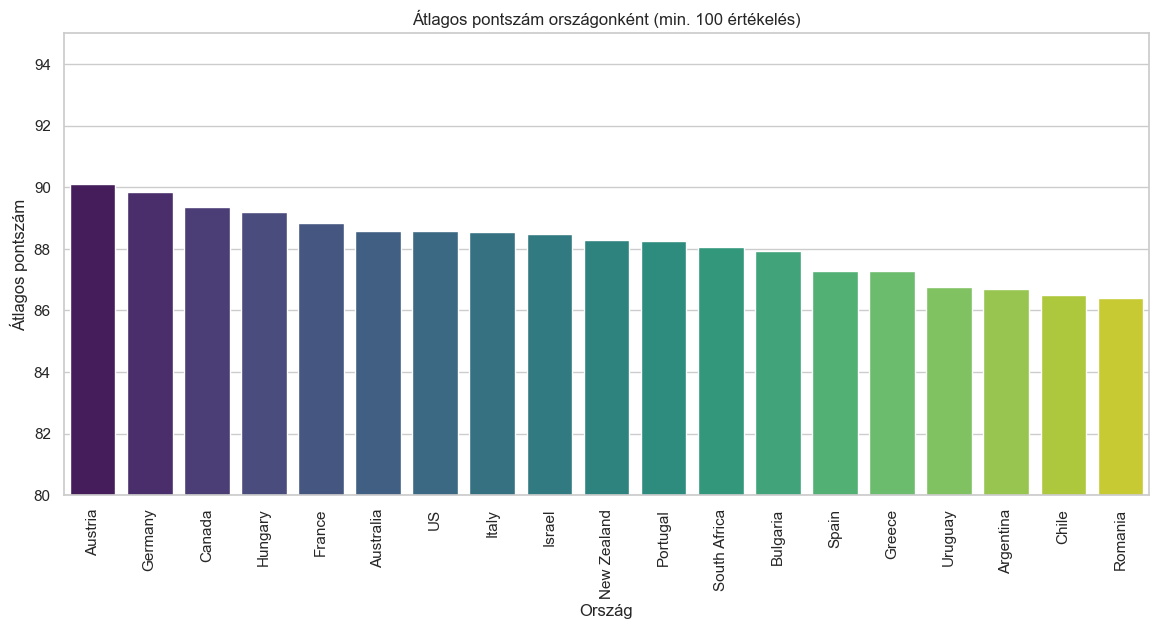

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Beállítások a szebb grafikonokért
sns.set_theme(style="whitegrid")

# Biztosítjuk, hogy a points oszlop numerikus legyen a vizualizációhoz
df_description['points'] = df_description['points'].astype(int)

# 1. Országok szerinti átlagos pontszám vizsgálata
# Csak azok az országok, ahol van elég adat (pl. több mint 100 értékelés), hogy elkerüljük a torzítást
country_counts = df_description['country'].value_counts()
valid_countries = country_counts[country_counts > 100].index
df_filtered_country = df_description[df_description['country'].isin(valid_countries)]

# Átlagos pontszám országonként
country_avg_points = df_filtered_country.groupby('country')['points'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(x=country_avg_points.index, y=country_avg_points.values, palette="viridis")
plt.xticks(rotation=90)
plt.title('Átlagos pontszám országonként (min. 100 értékelés)')
plt.ylabel('Átlagos pontszám')
plt.xlabel('Ország')
plt.ylim(80, 95) # A skála szűkítése a jobb láthatóságért
plt.show()

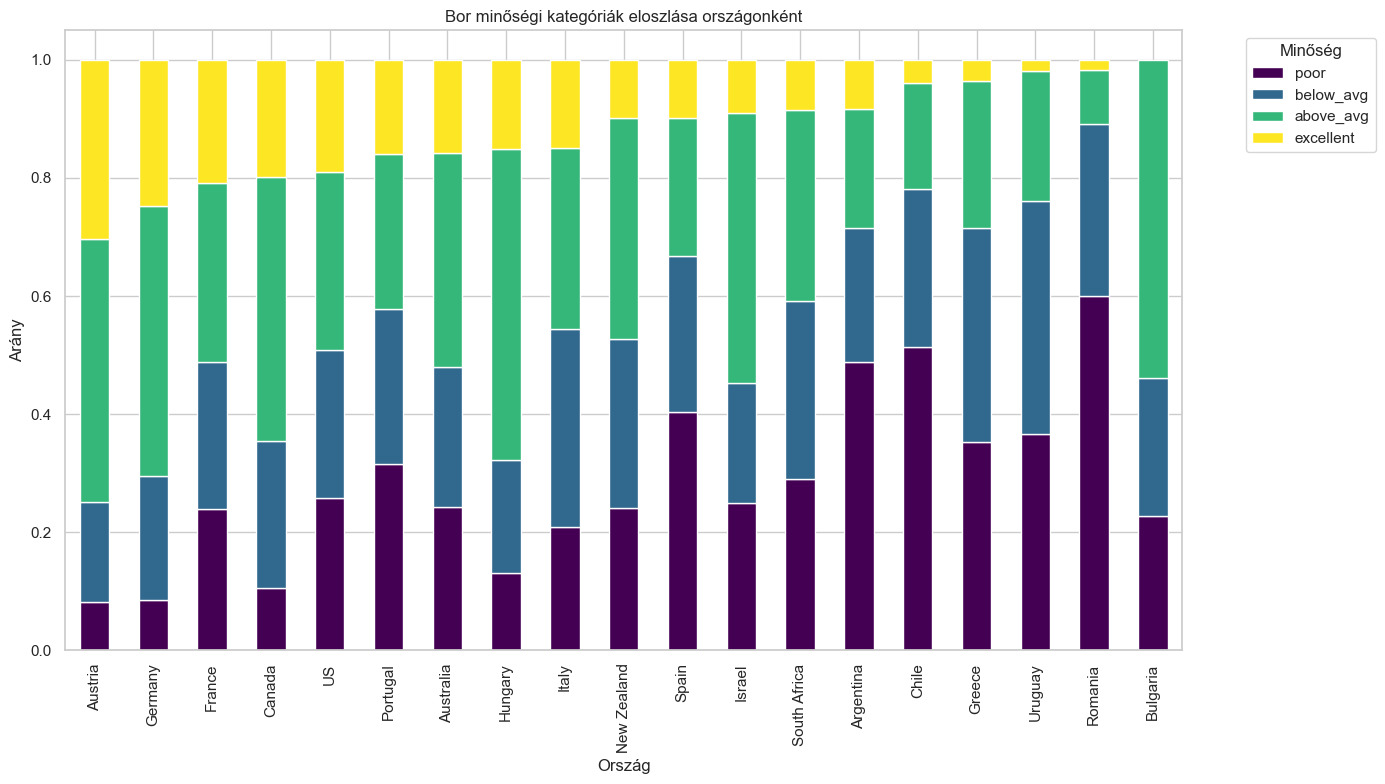

In [7]:
# 2. Minőségi kategóriák eloszlása országonként
# Ez megmutatja, hogy egy adott országból származó bor mekkora eséllyel esik egy bizonyos minőségi kategóriába

# Kereszttábla készítése és normalizálása (százalékos eloszlás)
ct = pd.crosstab(df_filtered_country['country'], df_filtered_country['group'], normalize='index')

# Rendezés: azon országok kerüljenek előre, ahol a legnagyobb az "excellent" borok aránya
ct = ct.reindex(ct.sort_values(by='excellent', ascending=False).index)

# Stacked bar chart
ct.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='viridis')
plt.title('Bor minőségi kategóriák eloszlása országonként')
plt.ylabel('Arány')
plt.xlabel('Ország')
plt.legend(title='Minőség', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

C:\Users\2314l\AppData\Local\Temp\ipykernel_19848\2214877352.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='province', y='points', data=df_top_provinces, order=top_provinces, palette="Set3")


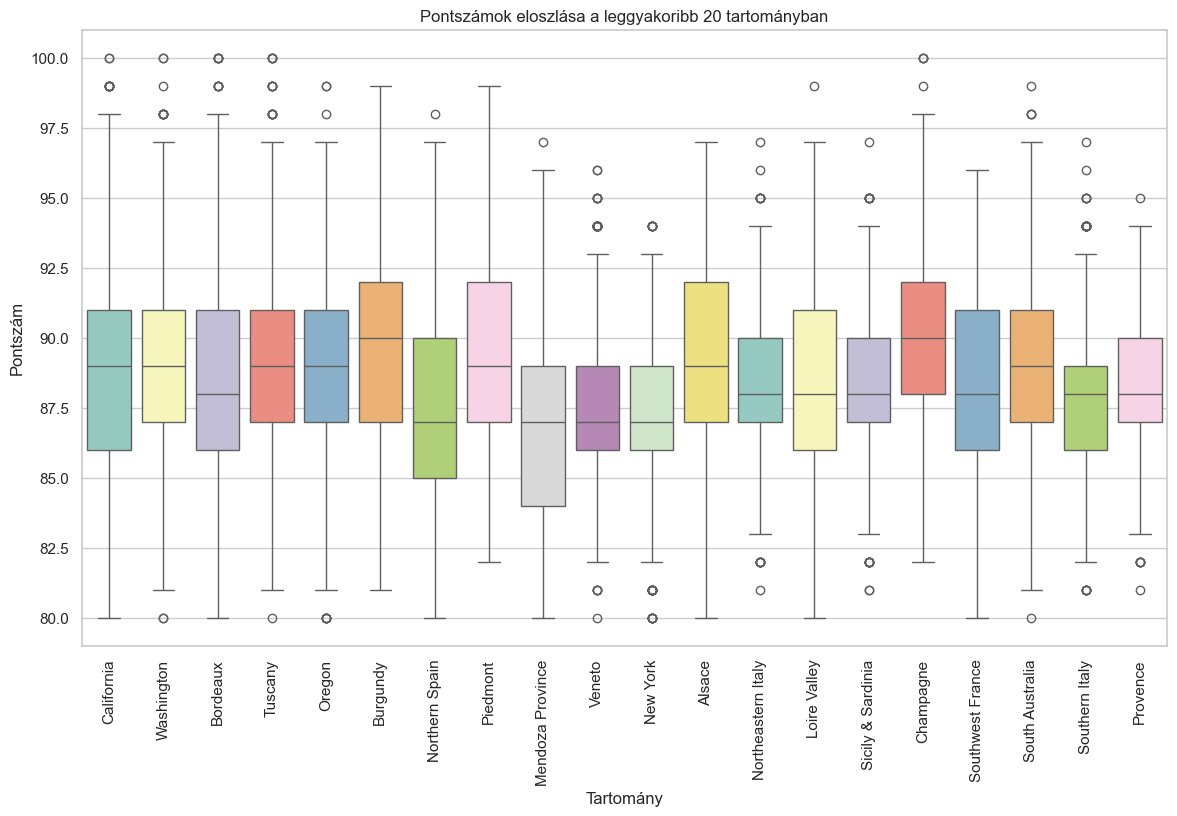

In [8]:
# 3. Tartományok (Province) vizsgálata
# Mivel nagyon sok tartomány van, a 20 leggyakoribbat vizsgáljuk meg

top_provinces = df_description['province'].value_counts().head(20).index
df_top_provinces = df_description[df_description['province'].isin(top_provinces)]

plt.figure(figsize=(14, 8))
# Boxplot segítségével láthatjuk az eloszlást és a kiugró értékeket is
sns.boxplot(x='province', y='points', data=df_top_provinces, order=top_provinces, palette="Set3")
plt.xticks(rotation=90)
plt.title('Pontszámok eloszlása a leggyakoribb 20 tartományban')
plt.ylabel('Pontszám')
plt.xlabel('Tartomány')
plt.show()